In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from shared.rlhc import random_latin_hypercube

# 2 Constructing a Surrogate

## 2.3 Radial Basis Function Models

$$f(x) = \bm{w}^T \bm{\psi} = \sum_{i=1}^{n_c}w_i\psi(\left\lVert x-c^{(i)} \right\rVert)$$

In [4]:
def appendix(x):
    return ((6*x - 2)**2) * np.sin((12*x) - 4)

def peaks(x, y):
    return (3 * (1 - x)**2 * np.exp(-x**2 - (y + 1)**2)
            - 10 * (x/5 - x**3 - y**5) * np.exp(-x**2 - y**2)
            - 1/3 * np.exp(-(x + 1)**2 - y**2))

In [72]:
def psi(r: np.ndarray, code: int = 1, sigma: float = None):
    
    match code:
        case 1: # linear
            return r
        case 2: # cubic
            return r**3
        case 3:  # thin plate spline
            # claude explained boolean indexing in numpy, very cool
            result = np.zeros_like(r)
            nz = r > 0
            result[nz] = (r[nz]**2) * np.log(r[nz])
            return result
        case 4: # Gaussian
            return np.exp(-(r**2)/(2*(sigma**2)))
        case 5: # multi-quadratic
            return np.sqrt(r**2 + sigma**2)
        case 6: # inverse multi-quadratic
            return 1 / (np.sqrt(r**2 + sigma**2))


# def psi_gram_matrix(XA: np.ndarray, XB: np.ndarray, code: int = 1) -> np.ndarray:
    # original approach
    # n = X.shape[0]
    # PSI = np.zeros((n,n))

    # for i in range(n):
    #     for j in range(n):
    #         dist = np.linalg.norm(XA[i] - XB[j])
    #         PSI[i,j] = psi(dist,code)
    # return PSI

    # claude suggestion
    # D = cdist(XA, XB)
    # return psi(D, code)


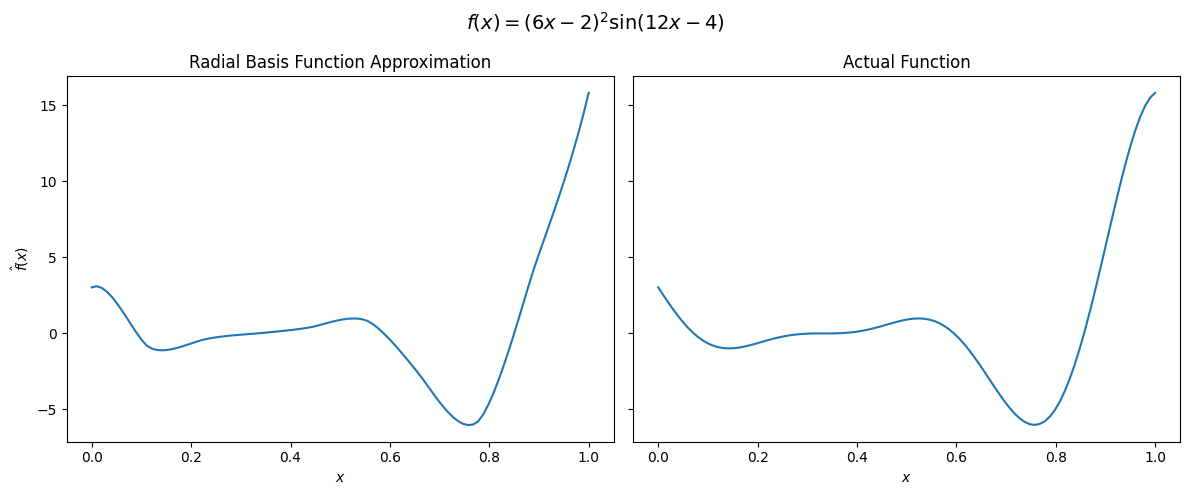

In [75]:
# 1D APPENDIX EXAMPLE
X_sample   = np.linspace(0,1,10).reshape(-1,1)
Y_sample   = appendix(X_sample)

D_sample   = cdist(X_sample, X_sample)
PSI_sample = psi(D_sample, 3)

W = np.linalg.solve(PSI_sample, Y_sample)

X   = np.linspace(0,1,100).reshape(-1,1)
D   = cdist(X, X_sample)
PSI = psi(D, 3)

func_latex = r'$f(x) = (6x - 2)^2 \sin(12x - 4)$'

fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

# --- RBF approximation ---
y = PSI @ W
ax1.plot(X, y)
ax1.set_title('Radial Basis Function Approximation')
ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$\hat{f}(x)$')

# --- Actual function ---
y = appendix(X)
ax2.plot(X, y)
ax2.set_title('Actual Function')
ax2.set_xlabel(r'$x$')

fig.suptitle(func_latex, fontsize=14)
plt.tight_layout()
plt.show()

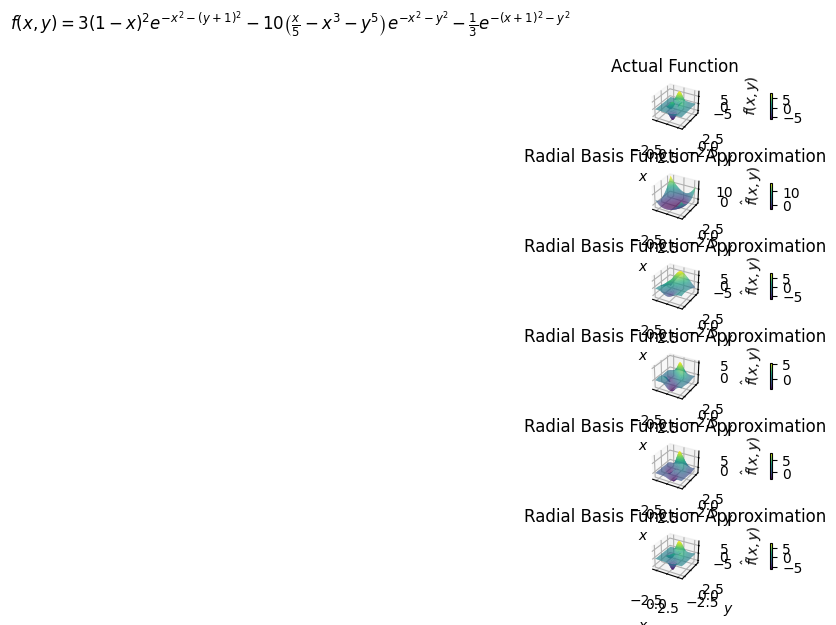

In [ ]:
func_latex = (r'$f(x,y) = 3(1-x)^2 e^{-x^2-(y+1)^2} '
              r'- 10\left(\frac{x}{5} - x^3 - y^5\right) e^{-x^2-y^2} '
              r'- \frac{1}{3} e^{-(x+1)^2-y^2}$')

# --- Evaluate both surfaces on a grid ---
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
matr = np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1))))

Z_true = peaks(X, Y)

# --- Plot side by side ---
sample_sizes = [5,10,25,50,100]
n_plots = len(sample_sizes) + 1 

fig = plt.figure(figsize=(8, 6*n_plots))

ax = fig.add_subplot(n_plots, 1, 1, projection='3d')
surf2 = ax.plot_surface(X, Y, Z_true, cmap='viridis', linewidth=0, antialiased=True)
ax.set_title('Actual Function')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_zlabel(r'$f(x,y)$')
fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=10)

for i, size in enumerate(sample_sizes):

    # --- Fit the RBF surrogate ---
    X_sample   = random_latin_hypercube(size, 2, -3, 3)
    D_sample   = cdist(X_sample, X_sample)
    PSI_sample = psi(D_sample, 3)
    Z_sample   = peaks(X_sample[:, 0], X_sample[:, 1])
    W = np.linalg.solve(PSI_sample, Z_sample)

    D    = cdist(matr, X_sample)
    PSI  = psi(D, 3)
    Z_rbf  = (PSI @ W).reshape((200, 200))

    ax2 = fig.add_subplot(n_plots, 1, i+2, projection='3d')
    surf1 = ax2.plot_surface(X, Y, Z_rbf, cmap='viridis', linewidth=0, antialiased=True)
    ax2.set_title('Radial Basis Function Approximation')
    ax2.set_xlabel(r'$x$')
    ax2.set_ylabel(r'$y$')
    ax2.set_zlabel(r'$\hat{f}(x,y)$')
    fig.colorbar(surf1, ax=ax2, shrink=0.5, aspect=10)

fig.suptitle(func_latex, fontsize=12)
plt.tight_layout()
plt.show()